In [ ]:
import numpy as np
from skimage.util import view_as_windows
import os
import shutil
import gc
from tensorflow.data import Dataset
from tensorflow import TensorSpec
import h5py
from sklearn.utils import shuffle
from tensorflow.keras import layers,models
from tensorflow.data import AUTOTUNE
from tensorflow import optimizers
from tensorflow import losses
from tensorflow.keras import callbacks

In [ ]:
def extract_patches(image, patch_size=(19, 19), stride=19):
    h, w, u = image.shape
    m, n = patch_size
    if m > h or n > w:
        raise ValueError("Patch size is larger than image dimensions")
    pad_h = m // 2
    pad_w = n // 2
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='reflect')
    patches = view_as_windows(padded_image, (m, n, u), step=stride)
    patches = patches.reshape(-1, m, n, u)

    return patches


In [ ]:
!mkdir patches

In [ ]:
imgs = ["/content/drive/MyDrive/hsi data/canola/canola_1.npy",
        "/content/drive/MyDrive/hsi data/redroot/redroot_pigweed_1.npy",
        "/content/drive/MyDrive/hsi data/kochia/tmp/kochia_1.npy",
        "/content/drive/MyDrive/hsi data/waterhemp/tmp/waterhemp_1.npy",
        "/content/drive/MyDrive/hsi data/sugarbeet/sugarbeet_1.npy",
        "/content/drive/MyDrive/hsi data/soybean/soybean_1.npy",
        "/content/drive/MyDrive/hsi data/ragweed/ragweed_1.npy"
        ]
for path in imgs:
  shutil.copy(path,"/content/")
  local_path = os.path.basename(path)
  img = np.load(local_path)
  patches = extract_patches(img)
  name = os.path.splitext(os.path.basename(path))[0]
  np.save(f"/content/patches/{name}_patches.npy", patches)
  os.remove(local_path)

In [ ]:
class_mapping = {
    "canola": 0,
    "kochia": 1,
    "ragweed": 2,
    "redroot": 3,
    "soybean":4,
    "sugarbeet":5,
    "waterhemp":6,
}
imgs = ["/content/patches/canola_1_patches.npy",
        "/content/patches/redroot_pigweed_1_patches.npy",
        "/content/patches/kochia_1_patches.npy",
        "/content/patches/waterhemp_1_patches.npy",
        "/content/patches/sugarbeet_1_patches.npy",
        "/content/patches/soybean_1_patches.npy",
        "/content/patches/ragweed_1_patches.npy"
        ]
X = []
y = []
for path in imgs:
  tmpX = np.load(path)
  name = os.path.splitext(os.path.basename(path))[0].split("_")[0]
  X.extend(tmpX)
  y.extend(tmpX.shape[0]* [class_mapping[name]])
  del tmpX
gc.collect()

88

In [ ]:
np.save('X_data.npy', X)
np.save('y_data.npy', y)

In [ ]:
!cp "/content/X_data.npy" "/content/drive/MyDrive/hsi data/ds_2d_3d/"
!cp "/content/y_data.npy" "/content/drive/MyDrive/hsi data/ds_2d_3d/"


In [ ]:
!cp "/content/drive/MyDrive/hsi data/ds_2d_3d/X_data.npy" "/content/"
!cp "/content/drive/MyDrive/hsi data/ds_2d_3d/y_data.npy" "/content/"

In [ ]:
def convert_npy_to_hdf5(npy_x_path, npy_y_path, hdf5_path):
    X_memmap = np.load(npy_x_path, mmap_mode="r")
    n_samples = X_memmap.shape[0]
    patch_shape = X_memmap.shape[1:]
    del X_memmap
    gc.collect()

    with h5py.File(hdf5_path, "w") as f:
        X_dset = f.create_dataset("X", (n_samples, *patch_shape, 1), dtype="float32")
        y_dset = f.create_dataset("y", (n_samples,), dtype="int32")

        batch_size = 1000
        for i in range(0, n_samples, batch_size):
            X_batch = np.load(npy_x_path, mmap_mode="r")[i:i+batch_size]
            y_batch = np.load(npy_y_path, mmap_mode="r")[i:i+batch_size]

            X_batch = np.array(X_batch, dtype=np.float32)
            y_batch = np.array(y_batch, dtype=np.int32)

            X_dset[i:i+batch_size] = X_batch[..., np.newaxis]
            y_dset[i:i+batch_size] = y_batch

            del X_batch, y_batch
            gc.collect()

hdf5_path = "/content/X_y_patches.h5"
if not os.path.exists(hdf5_path):
    convert_npy_to_hdf5("/content/X_data.npy", "/content/y_data.npy", hdf5_path)

with h5py.File(hdf5_path, "r") as f:
    n_samples = f["X"].shape[0]
train_size = int(n_samples * 0.7)
val_size = int(n_samples * 0.9)

indices = np.arange(n_samples)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:val_size]
test_indices = indices[val_size:]

def make_generator(hdf5_path, indices):
    def generator():
        with h5py.File(hdf5_path, "r") as f:
            for idx in indices:
                yield f["X"][idx], f["y"][idx]
    return generator

dataset_train = Dataset.from_generator(
    make_generator(hdf5_path, train_indices),
    output_signature=(
        TensorSpec(shape=(19, 19, 224, 1), dtype=np.float32),
        TensorSpec(shape=(), dtype=np.int32)
    )
)

dataset_val = Dataset.from_generator(
    make_generator(hdf5_path, val_indices),
    output_signature=(
        TensorSpec(shape=(19, 19, 224, 1), dtype=np.float32),
        TensorSpec(shape=(), dtype=np.int32)
    )
)

dataset_test = Dataset.from_generator(
    make_generator(hdf5_path, test_indices),
    output_signature=(
        TensorSpec(shape=(19, 19, 224, 1), dtype=np.float32),
        TensorSpec(shape=(), dtype=np.int32)
    )
)


In [ ]:
def build_model(input_shape = (19,19,224,1)):
  inp = layers.Input(input_shape)
  inp = layers.Reshape((19,19,224))(inp)
  conv1 = layers.Conv2D(128,kernel_size = (3,3),padding = "same")(inp)
  conv1 = layers.Activation("relu")(conv1)
  pool1 = layers.MaxPooling2D( pool_size = (2,2))(conv1)

  pool1 = layers.Reshape((9,9,128,1))(pool1)
  conv2 = layers.Conv3D(1,kernel_size = (1,1,8),strides = (1,1,5))(pool1)
  conv2 = layers.Activation("relu")(conv2)
  pool2 = layers.MaxPooling3D((2,2,1))(conv2)
  conv3 = layers.Conv3DTranspose(200,kernel_size=(3,3,39),padding = "same")(pool2)

  flat = layers.Flatten()(conv3)
  dense1 = layers.Dense(200,"relu")(flat)
  dense2 = layers.Dense(7,"softmax")(dense1)
  output = dense2
  model = models.Model(inp,output)
  return model



In [ ]:
model = build_model()
print(model.summary())

opt = optimizers.Adam(learning_rate = 1e-3)
model.compile(optimizer=opt,loss = losses.SparseCategoricalCrossentropy(),metrics = ["accuracy"])

chechpoint = callbacks.ModelCheckpoint("/content/drive/MyDrive/hsi data/2d-3d_ver2.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only = True)
tb = callbacks.TensorBoard(
    log_dir="/content/logs",
    histogram_freq=1)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_14CLONE            │ (None, 19, 19, 224)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 19, 128)    │       258,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 9, 9, 128, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 9, 9, 25, 1)    │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 9, 9, 25, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 4, 4, 25, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_transpose_1              │ (None, 4, 4, 25, 200)  │        70,400 │
│ (Conv3DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │    16,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,330,192 (62.29 MB)

 Trainable params: 16,330,192 (62.29 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
dataset_train = dataset_train.batch(100).shuffle(buffer_size=train_size).prefetch(AUTOTUNE)
dataset_val = dataset_val.batch(100).prefetch(AUTOTUNE)
dataset_test = dataset_test.batch(100).prefetch(AUTOTUNE)

In [ ]:
batch_size = 100
steps_per_epoch = train_size // batch_size
history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    callbacks=[chechpoint, tb]
)

In [ ]:
test_loss,test_acc = model.evaluate(dataset_test)
print(test_loss,test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 970ms/step - accuracy: 0.7860 - loss: 0.8763
0.9311895370483398 0.7771173715591431


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


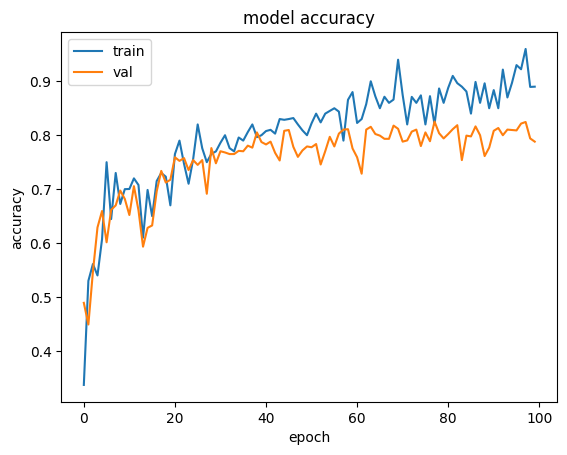

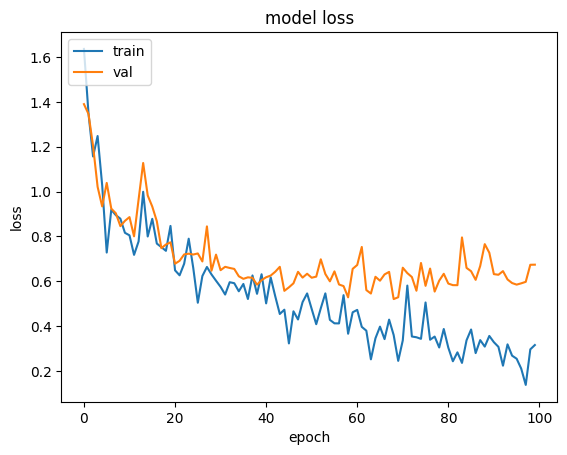

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],markersize=20)
plt.plot(history.history['val_accuracy'], markersize=20)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()